In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import torch
from ncpu.runner  import TrainRunnerUI, setup_trainer, setup_pool_trainer
from ncpu.config import BIG_CONJUNCTION_TRAINING_CONFIG, TINY_CONJUNCTION_TRAINING_CONFIG, TINY_NAND_TRAINING_CONFIG
import mediapy as media

In [2]:
trainer = setup_pool_trainer(TINY_NAND_TRAINING_CONFIG)

self.dataloader: <ncpu.dataset.PoolLoader object at 0x7abff550b230>
Sanity check...
  forward: torch.Size([2, 16, 32, 32]) -> torch.Size([2, 11, 16, 32, 32])
  batch: 2
  dataloader: torch.Size([16, 32, 32]) -> torch.Size([16, 32, 32])
  first_state: torch.Size([16, 16, 32, 32])
  rollout: torch.Size([16, 11, 16, 32, 32])
  loss: 0.04973740130662918
Sanity check completed successfully


In [9]:
state_dict = torch.load("checkpoints/ncpu_pooled_final_one_class_learned_99252_20251205_221840.pth")
trainer.nca.load_state_dict(state_dict)

<All keys matched successfully>

loss=0.010468:   0%|          | 171/200000 [02:11<1:16:51, 43.33it/s]

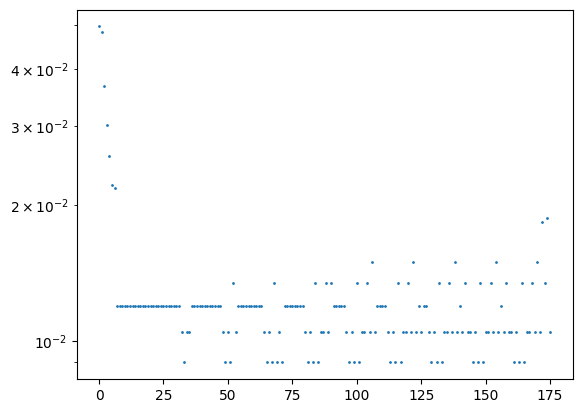

inp    : (16, 32, 32) torch.float32, min=-0.00, max=1.00, mean=0.05, std=0.19
out    : (16, 32, 32) torch.float32, min=0.00, max=1.00, mean=0.02, std=0.14
nca_out: (16, 32, 32) torch.float32, min=0.00, max=0.00, mean=0.00, std=0.00


,,,,,,,
,,,,,,,
,,,,,,,

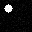
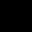
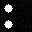
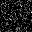
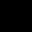
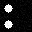
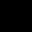
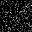
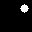
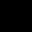
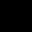
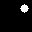
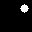
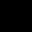
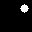
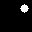
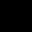
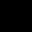
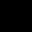
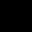
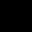
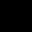
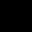
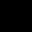

#0,#1,#2,#3,#4,#5,#6,#7

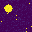
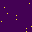
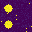
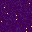
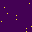
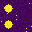
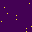
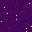

In [11]:
from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime
from ncpu.utils import print_tensor, sequence_batch_to_html_gifs

info = trainer.optim_step(pool=True)

clear_output(wait=False)
display(pbar.container)
plt.scatter(range(len(trainer.history)), trainer.history, s=1)
plt.yscale("log")
plt.show()

print_tensor("inp    ", info["inp"])
print_tensor("out    ", info["out"])
print_tensor("nca_out", info["nca_out"])

to_show = 8
inp = info["inp"][:to_show]
out = info["out"][:to_show]
nca_out = info["nca_out"][:to_show]
rollout = info["rollout"][:to_show]
io = torch.cat([inp, out, nca_out], dim=0)

media.show_images(io.detach().cpu(), columns=to_show, width=100, height=100)
sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

